# Hyperparameter Optimization

This notebook tunes the main regression models with cross-validation, compares their validation scores, and prepares the results for the final report.

The goal is to keep the preprocessing consistent with the modeling notebook while selecting the strongest configuration for each estimator.


In [1]:
# =========================================================
# 0. IMPORTS
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
os.makedirs("figures_tuning", exist_ok=True)

In [2]:
# =========================================================
# 1. CHARGEMENT DES DONNEES
# =========================================================

DATA_PATH = r"student_dataset/student_failure/train.csv"

df = pd.read_csv(DATA_PATH)
print("Shape raw dataset:", df.shape)
df.head()

Shape raw dataset: (630000, 15)


,id,age,genre,diplôme,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,méthode_etude,évaluation_établissement,difficulté_examen,score_examen,heures_fête,taille_etudiant
0,0,21,male,Computer Science,7.91,98.8,NaN,4.9,average,online videos,low,easy,75.02,5,1.91
1,1,18,female,Law,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,49.03,4,1.89
2,2,20,female,Computer Science,4.68,92.6,NaN,5.8,poor,coaching,high,moderate,100.00,4,1.72
3,3,19,male,Computer Science,2.00,49.5,yes,8.3,average,group study,high,moderate,63.90,4,1.51
4,4,23,female,Business Management,7.65,86.9,yes,9.6,good,self-study,high,easy,100.00,2,1.94


In [3]:
# =========================================================
# 2. PREPROCESSING IDENTIQUE AU NOTEBOOK MODELE
# =========================================================

df_ml = df.copy()

# Suppression de l'id
if "id" in df_ml.columns:
    df_ml = df_ml.drop(columns=["id"])

# Suppression des doublons
n_before = len(df_ml)
df_ml = df_ml.drop_duplicates()
print(f"Doublons supprimés : {n_before - len(df_ml)}")

# Gestion des valeurs manquantes
num_cols = df_ml.select_dtypes(include=np.number).columns
cat_cols = df_ml.select_dtypes(include="object").columns

df_ml[num_cols] = df_ml[num_cols].fillna(df_ml[num_cols].mean())
df_ml[cat_cols] = df_ml[cat_cols].fillna("unknown")

# Encodage binaire
if "genre" in df_ml.columns:
    df_ml["genre"] = df_ml["genre"].map({"male": 0, "female": 1}).fillna(0)

if "accès_internet" in df_ml.columns:
    df_ml["accès_internet"] = df_ml["accès_internet"].map({"yes": 1, "no": 0}).fillna(0)

# Encodage ordinal
if "qualité_sommeil" in df_ml.columns:
    df_ml["qualité_sommeil"] = df_ml["qualité_sommeil"].map({
        "poor": 0,
        "average": 1,
        "good": 2,
        "excellent": 3
    }).fillna(1)

if "évaluation_établissement" in df_ml.columns:
    df_ml["évaluation_établissement"] = df_ml["évaluation_établissement"].map({
        "low": 0,
        "medium": 1,
        "high": 2
    }).fillna(1)

if "difficulté_examen" in df_ml.columns:
    df_ml["difficulté_examen"] = df_ml["difficulté_examen"].map({
        "easy": 0,
        "moderate": 1,
        "hard": 2
    }).fillna(1)

# One-hot encoding
nominal_cols = [col for col in ["diplôme", "méthode_etude"] if col in df_ml.columns]
df_ml = pd.get_dummies(df_ml, columns=nominal_cols, drop_first=True)

# Conversion bool -> float
df_ml = df_ml.astype(float)

print("Shape after preprocessing:", df_ml.shape)
df_ml.head()

Doublons supprimés : 0


C:\Users\louis\AppData\Local\Temp\ipykernel_16812\642246179.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_ml.select_dtypes(include="object").columns


Shape after preprocessing: (630000, 23)


,age,genre,heures_etude,assiduité_classe,accès_internet,heures_sommeil,qualité_sommeil,évaluation_établissement,difficulté_examen,score_examen,...,diplôme_Business Management,diplôme_Computer Science,diplôme_Engineering,diplôme_Law,diplôme_Marketing,méthode_etude_group study,méthode_etude_mixed,méthode_etude_online videos,méthode_etude_self-study,méthode_etude_unknown
0,21.0,0.0,7.91,98.8,0.0,4.9,1.0,0.0,0.0,75.02,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,18.0,1.0,4.95,94.8,1.0,4.7,0.0,1.0,1.0,49.03,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,20.0,1.0,4.68,92.6,0.0,5.8,0.0,2.0,1.0,100.00,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,19.0,0.0,2.00,49.5,1.0,8.3,1.0,2.0,1.0,63.90,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,23.0,1.0,7.65,86.9,1.0,9.6,2.0,2.0,0.0,100.00,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [4]:
# =========================================================
# 3. SELECTION DES FEATURES
# =========================================================

selected_features = [
    "heures_etude",
    "genre",
    "assiduité_classe",
    "heures_sommeil",
    "qualité_sommeil",
    "évaluation_établissement",
    "accès_internet",
    "diplôme_Engineering",
    "diplôme_Marketing",
    "diplôme_Computer Science"
]

selected_features = [col for col in selected_features if col in df_ml.columns]

X = df_ml[selected_features]
y = df_ml["score_examen"]

print("Features utilisées:")
print(X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

Features utilisées:
['heures_etude', 'genre', 'assiduité_classe', 'heures_sommeil', 'qualité_sommeil', 'évaluation_établissement', 'accès_internet', 'diplôme_Engineering', 'diplôme_Marketing', 'diplôme_Computer Science']
X shape: (630000, 10)
y shape: (630000,)


In [5]:
# =========================================================
# 4. TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (504000, 10)
Test size: (126000, 10)


## 1. Tuning sample

Le dataset est très grand. Pour éviter que le tuning soit trop long, on optimise les hyperparamètres sur un sous-échantillon du training set. Ensuite, le meilleur modèle est réentraîné sur tout le training set.

In [6]:
# =========================================================
# 5. SOUS-ECHANTILLON POUR LE TUNING
# =========================================================
TUNING_SAMPLE_SIZE = 80_000

if len(X_train) > TUNING_SAMPLE_SIZE:
    X_tune = X_train.sample(TUNING_SAMPLE_SIZE, random_state=RANDOM_STATE)
    y_tune = y_train.loc[X_tune.index]
else:
    X_tune = X_train.copy()
    y_tune = y_train.copy()

print("Tuning sample size:", X_tune.shape)

Tuning sample size: (80000, 10)


## 2. Hyperparameter optimization with GridSearchCV

A hyperparameter is a value chosen before training the model. Here, several values are tested for each model:
- Ridge Regression: regularization strength `alpha`;
- Decision Tree: tree depth and minimum samples per leaf;
- Random Forest: number of trees, tree depth and minimum samples per leaf.

The best configuration is selected using 3-fold cross-validation and the validation RMSE.

In [7]:
# =========================================================
# 6. ADVANCED HYPERPARAMETER OPTIMIZATION
# =========================================================

from sklearn.model_selection import KFold, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, uniform, loguniform
import pandas as pd
import numpy as np
import time

cv = KFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)

# =========================================================
# 6.1 BROAD RANDOM SEARCH
# =========================================================

models_random_search = {
    "Ridge Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge())
        ]),
        "params": {
            # loguniform allows to test values over several orders of magnitude
            "ridge__alpha": loguniform(1e-4, 1e3)
        },
        "n_iter": 80
    },

    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "params": {
            "max_depth": [None] + list(range(2, 41)),
            "min_samples_split": randint(2, 100),
            "min_samples_leaf": randint(1, 80),
            "max_leaf_nodes": [None] + list(range(20, 501)),
            "ccp_alpha": loguniform(1e-6, 1e-1)
        },
        "n_iter": 120
    },

    "Random Forest": {
        "model": RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            bootstrap=True
        ),
        "params": {
            "n_estimators": randint(100, 600),
            "max_depth": [None] + list(range(5, 41)),
            "min_samples_split": randint(2, 80),
            "min_samples_leaf": randint(1, 50),
            "max_features": ["sqrt", "log2", 0.5, 0.7, 1.0],
            "bootstrap": [True]
        },
        "n_iter": 20
    }
}

random_search_results = []
random_best_params = {}
random_best_models = {}

for name, config in models_random_search.items():
    print(f"\n===== Randomized Search: {name} =====")
    start_time = time.time()

    random_search = RandomizedSearchCV(
        estimator=config["model"],
        param_distributions=config["params"],
        n_iter=config["n_iter"],
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        return_train_score=True,
        verbose=1
    )

    random_search.fit(X_tune, y_tune)

    elapsed_time = time.time() - start_time
    best_cv_rmse = -random_search.best_score_

    random_best_params[name] = random_search.best_params_
    random_best_models[name] = random_search.best_estimator_

    random_search_results.append({
        "Model": name,
        "Best random search parameters": random_search.best_params_,
        "Best CV RMSE": best_cv_rmse,
        "Time (s)": elapsed_time
    })

    print("Best parameters:", random_search.best_params_)
    print(f"Best CV RMSE: {best_cv_rmse:.4f}")
    print(f"Time: {elapsed_time/60:.2f} minutes")

random_search_df = pd.DataFrame(random_search_results).sort_values("Best CV RMSE")
random_search_df


===== Randomized Search: Ridge Regression =====
Fitting 2 folds for each of 80 candidates, totalling 160 fits
Best parameters: {'ridge__alpha': np.float64(13.3032451015229)}
Best CV RMSE: 9.8612
Time: 0.15 minutes

===== Randomized Search: Decision Tree =====
Fitting 2 folds for each of 120 candidates, totalling 240 fits
Best parameters: {'ccp_alpha': np.float64(1.2898495377182665e-05), 'max_depth': 24, 'max_leaf_nodes': 481, 'min_samples_leaf': 59, 'min_samples_split': 33}
Best CV RMSE: 10.4247
Time: 0.12 minutes

===== Randomized Search: Random Forest =====
Fitting 2 folds for each of 20 candidates, totalling 40 fits
Best parameters: {'bootstrap': True, 'max_depth': 14, 'max_features': 0.5, 'min_samples_leaf': 17, 'min_samples_split': 9, 'n_estimators': 262}
Best CV RMSE: 9.9441
Time: 1.36 minutes


,Model,Best random search parameters,Best CV RMSE,Time (s)
0,Ridge Regression,{'ridge__alpha': 13.3032451015229},9.861165,9.112514
2,Random Forest,"{'bootstrap': True, 'max_depth': 14, 'max_feat...",9.944059,81.573940
1,Decision Tree,"{'ccp_alpha': 1.2898495377182665e-05, 'max_dep...",10.424659,7.167634


In [8]:
# =========================================================
# 6.2 LOCAL GRID SEARCH AROUND BEST RANDOM SEARCH RESULTS
# =========================================================

def ridge_fine_grid(best_params):
    best_alpha = best_params["ridge__alpha"]
    return {
        "ridge__alpha": [
            best_alpha / 10,
            best_alpha / 3,
            best_alpha,
            best_alpha * 3,
            best_alpha * 10
        ]
    }


def decision_tree_fine_grid(best_params):
    best_depth = best_params["max_depth"]
    best_leaf = best_params["min_samples_leaf"]
    best_split = best_params["min_samples_split"]
    best_nodes = best_params["max_leaf_nodes"]
    best_ccp = best_params["ccp_alpha"]

    depth_values = [best_depth]
    if best_depth is not None:
        depth_values = sorted(set([
            max(1, best_depth - 5),
            max(1, best_depth - 2),
            best_depth,
            best_depth + 2,
            best_depth + 5
        ]))

    node_values = [best_nodes]
    if best_nodes is not None:
        node_values = sorted(set([
            max(10, best_nodes - 50),
            max(10, best_nodes - 20),
            best_nodes,
            best_nodes + 20,
            best_nodes + 50
        ]))

    return {
        "max_depth": depth_values,
        "min_samples_leaf": sorted(set([
            max(1, best_leaf - 10),
            max(1, best_leaf - 5),
            best_leaf,
            best_leaf + 5,
            best_leaf + 10
        ])),
        "min_samples_split": sorted(set([
            max(2, best_split - 10),
            max(2, best_split - 5),
            best_split,
            best_split + 5,
            best_split + 10
        ])),
        "max_leaf_nodes": node_values,
        "ccp_alpha": [
            best_ccp / 10,
            best_ccp / 3,
            best_ccp,
            best_ccp * 3,
            best_ccp * 10
        ]
    }


def random_forest_fine_grid(best_params):
    best_n = best_params["n_estimators"]
    best_depth = best_params["max_depth"]
    best_leaf = best_params["min_samples_leaf"]
    best_split = best_params["min_samples_split"]
    best_features = best_params["max_features"]

    depth_values = [best_depth]
    if best_depth is not None:
        depth_values = sorted(set([
            max(1, best_depth - 5),
            max(1, best_depth - 2),
            best_depth,
            best_depth + 2,
            best_depth + 5
        ]))

    return {
        "n_estimators": sorted(set([
            max(50, best_n - 100),
            max(50, best_n - 50),
            best_n,
            best_n + 50,
            best_n + 100
        ])),
        "max_depth": depth_values,
        "min_samples_leaf": sorted(set([
            max(1, best_leaf - 5),
            max(1, best_leaf - 2),
            best_leaf,
            best_leaf + 2,
            best_leaf + 5
        ])),
        "min_samples_split": sorted(set([
            max(2, best_split - 10),
            max(2, best_split - 5),
            best_split,
            best_split + 5,
            best_split + 10
        ])),
        "max_features": [best_features],
        "bootstrap": [True]
    }


fine_search_configs = {
    "Ridge Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge())
        ]),
        "params": ridge_fine_grid(random_best_params["Ridge Regression"])
    },

    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "params": decision_tree_fine_grid(random_best_params["Decision Tree"])
    },

    "Random Forest": {
        "model": RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "params": random_forest_fine_grid(random_best_params["Random Forest"])
    }
}

best_models = {}
fine_tuning_rows = []

for name, config in fine_search_configs.items():
    print(f"\n===== Fine Grid Search: {name} =====")
    start_time = time.time()

    grid_search = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        return_train_score=True,
        verbose=1
    )

    grid_search.fit(X_tune, y_tune)

    elapsed_time = time.time() - start_time
    best_cv_rmse = -grid_search.best_score_

    # Retrain best model on the full training set
    best_model = grid_search.best_estimator_
    best_model.fit(X_train, y_train)
    best_models[name] = best_model

    fine_tuning_rows.append({
        "Model": name,
        "Best hyperparameters": grid_search.best_params_,
        "Best CV RMSE": best_cv_rmse,
        "Time (s)": elapsed_time
    })

    print("Best parameters:", grid_search.best_params_)
    print(f"Best CV RMSE: {best_cv_rmse:.4f}")
    print(f"Time: {elapsed_time/60:.2f} minutes")

fine_tuning_df = pd.DataFrame(fine_tuning_rows).sort_values("Best CV RMSE")
fine_tuning_df


===== Fine Grid Search: Ridge Regression =====
Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best parameters: {'ridge__alpha': np.float64(13.3032451015229)}
Best CV RMSE: 9.8612
Time: 0.01 minutes

===== Fine Grid Search: Decision Tree =====
Fitting 2 folds for each of 3125 candidates, totalling 6250 fits


KeyboardInterrupt: 

In [ ]:
# =========================================================
# 6.3 FINAL EVALUATION ON TEST SET
# =========================================================

final_results = []

for name, model in best_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    final_results.append({
        "Model": name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "RMSE gap": test_rmse - train_rmse
    })

final_results_df = pd.DataFrame(final_results).sort_values("Test RMSE")
final_results_df

In [ ]:
# =========================================================
# 6.4 PLOT FINAL RESULTS
# =========================================================

import matplotlib.pyplot as plt
import os

os.makedirs("figures_tuning", exist_ok=True)

plot_df = final_results_df.set_index("Model")[["Test MAE", "Test RMSE"]]

plt.figure(figsize=(9, 5))
plot_df.plot(kind="bar", figsize=(9, 5))
plt.title("Model comparison after advanced hyperparameter tuning")
plt.ylabel("Error")
plt.xlabel("Model")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("figures_tuning/advanced_hyperparameter_tuning_results.png", dpi=300)
plt.show()

## 3. Final evaluation of tuned models

After tuning, each best model is retrained on the full training set and evaluated on the independent test set. This makes the model comparison fairer.

In [ ]:
# =========================================================
# 7. FINAL EVALUATION AFTER TUNING
# =========================================================

def compute_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

results_rows = []

# Baseline model: always predicts the mean score of the training set.
baseline_test_pred = np.full(len(y_test), y_train.mean())
baseline_metrics = compute_metrics(y_test, baseline_test_pred)

results_rows.append({
    "Model": "Baseline",
    "Best hyperparameters": "None",
    "Test MAE": baseline_metrics["MAE"],
    "Test RMSE": baseline_metrics["RMSE"],
    "Test R2": baseline_metrics["R2"]
})

for _, row in tuning_df.iterrows():
    name = row["Model"]
    model = best_models[name]
    y_pred = model.predict(X_test)
    metrics = compute_metrics(y_test, y_pred)

    results_rows.append({
        "Model": name,
        "Best hyperparameters": row["Best hyperparameters"],
        "Test MAE": metrics["MAE"],
        "Test RMSE": metrics["RMSE"],
        "Test R2": metrics["R2"]
    })

results_df = pd.DataFrame(results_rows).sort_values("Test RMSE")
results_df

,Model,Best hyperparameters,Test MAE,Test RMSE,Test R2
1,Ridge Regression,{'ridge__alpha': 10},7.812568,9.828105,0.729508
2,Random Forest,"{'max_depth': 10, 'min_samples_leaf': 10, 'n_e...",7.922237,9.949805,0.722767
3,Decision Tree,"{'max_depth': 10, 'max_leaf_nodes': 200, 'min_...",8.338389,10.446864,0.694376
0,Baseline,None,15.545894,18.897375,-0.000042


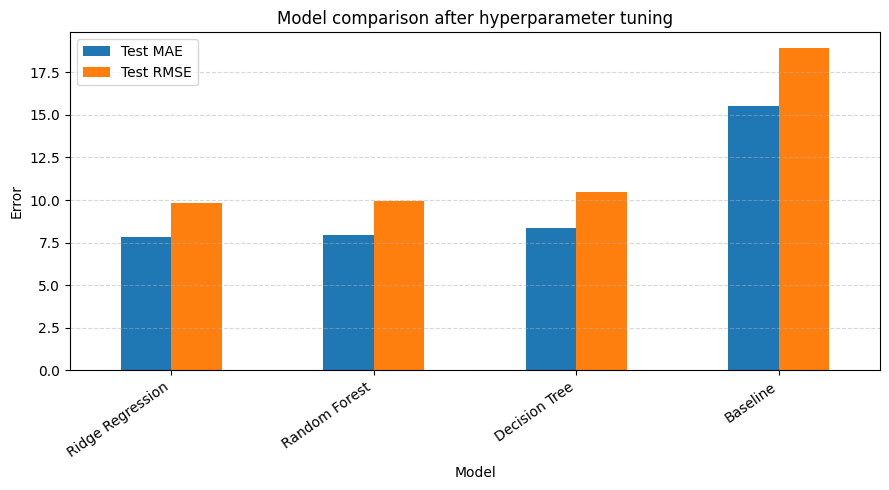

In [ ]:
# =========================================================
# 8. FIGURE: MODEL COMPARISON AFTER HYPERPARAMETER OPTIMIZATION
# =========================================================

plot_df = results_df.set_index("Model")[["Test MAE", "Test RMSE"]]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
plt.title("Model comparison after hyperparameter tuning")
plt.ylabel("Error")
plt.xlabel("Model")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig("figures_tuning/model_comparison_after_hyperparameter_tuning.png", dpi=300)
plt.show()